# 2주차 실습: 토큰화 알고리즘 탐구

**자연어정보분석 | 연세대학교 글로벌인재학부**

이 노트북에서는 다음을 체험합니다:
1. **토큰화 → 복원** 라운드트립 (tiktoken)
2. **이모지·특수문자** 토큰화 실험
3. **언어별 토큰 효율** 비교 (한/영/중/일)
4. **한국어 형태소 분석** + 품사 태깅 (KoNLPy)
5. **나만의 BPE 토크나이저** 직접 구현

In [1]:
# 환경 설정 — 필요한 라이브러리 설치
!pip install -q tiktoken transformers kiwipiepy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. 토큰화 → 복원 라운드트립

텍스트를 토큰 ID로 변환(encode)하고, 다시 원문으로 복원(decode)하는 과정을 확인합니다.
**핵심 질문**: 토큰화 후 복원하면 원문과 100% 동일한가?

In [2]:
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4")

# --- 영어 라운드트립 ---
en_text = "Natural language processing is amazing"
en_tokens = enc.encode(en_text)
en_restored = enc.decode(en_tokens)

print("=== 영어 ===")
print(f"원문:    {en_text}")
print(f"토큰 ID: {en_tokens}")
print(f"각 토큰: {[enc.decode([t]) for t in en_tokens]}")
print(f"복원:    {en_restored}")
print(f"일치?    {en_text == en_restored}")
print(f"토큰 수: {len(en_tokens)}")

print()

# --- 한국어 라운드트립 ---
ko_text = "자연어 처리는 놀랍습니다"
ko_tokens = enc.encode(ko_text)
ko_restored = enc.decode(ko_tokens)

print("=== 한국어 ===")
print(f"원문:    {ko_text}")
print(f"토큰 ID: {ko_tokens}")
print(f"각 토큰: {[enc.decode([t]) for t in ko_tokens]}")
print(f"복원:    {ko_restored}")
print(f"일치?    {ko_text == ko_restored}")
print(f"토큰 수: {len(ko_tokens)}")

print(f"\n→ 같은 의미인데 한국어가 {len(ko_tokens) - len(en_tokens)}개 더 많은 토큰 필요!")

=== 영어 ===
원문:    Natural language processing is amazing
토큰 ID: [55381, 4221, 8863, 374, 8056]
각 토큰: ['Natural', ' language', ' processing', ' is', ' amazing']
복원:    Natural language processing is amazing
일치?    True
토큰 수: 5

=== 한국어 ===
원문:    자연어 처리는 놀랍습니다
토큰 ID: [26799, 13879, 108, 32179, 82158, 16969, 5251, 228, 222, 39519, 235, 39331]
각 토큰: ['자', '�', '�', '어', ' 처리', '는', ' �', '�', '�', '�', '�', '습니다']
복원:    자연어 처리는 놀랍습니다
일치?    True
토큰 수: 12

→ 같은 의미인데 한국어가 7개 더 많은 토큰 필요!


## 2. 이모지·특수문자 토큰화 실험

이모지, 수학 기호, 코드 등 특수한 텍스트를 넣으면 어떻게 토큰화되는지 확인합니다.
BPE는 바이트 수준까지 분해하므로 어떤 입력이든 처리할 수 있습니다.

In [3]:
def analyze_tokens(text, label=""):
    """텍스트를 토큰화하고 각 토큰을 시각화"""
    tokens = enc.encode(text)
    parts = [enc.decode([t]) for t in tokens]
    print(f"{'['+label+'] ' if label else ''}({len(tokens)}토큰) {text}")
    print(f"  → {parts}")
    print()
    return len(tokens)

print("=" * 60)
print("이모지 토큰화 실험")
print("=" * 60)

# 이모지 테스트
analyze_tokens("Hello World 👋", "영어+이모지")
analyze_tokens("안녕하세요 🇰🇷", "한국어+국기이모지")
analyze_tokens("AI가 세상을 바꾸고 있다 🤖🌍✨", "한국어+이모지3개")
analyze_tokens("🎉🎊🥳🎈🎆", "이모지만 5개")

print("=" * 60)
print("특수 텍스트 토큰화")
print("=" * 60)

# 코드
analyze_tokens("print('hello world')", "Python 코드")
analyze_tokens("SELECT * FROM users WHERE id = 1;", "SQL")

# 수학
analyze_tokens("E = mc²", "물리 공식")
analyze_tokens("∑(i=1 to n) xᵢ", "수학 기호")

# 신조어/줄임말
analyze_tokens("ㅋㅋㅋㅋㅋ", "한국어 웃음")
analyze_tokens("ㅎㅇ ㅂㅂ ㄱㅅ", "한국어 자음 줄임말")
analyze_tokens("lol omg brb", "영어 줄임말")

이모지 토큰화 실험
[영어+이모지] (4토큰) Hello World 👋
  → ['Hello', ' World', ' �', '�']

[한국어+국기이모지] (11토큰) 안녕하세요 🇰🇷
  → ['�', '�', '�', '�', '하세요', ' �', '�', '�', '�', '�', '�']

[한국어+이모지3개] (20토큰) AI가 세상을 바꾸고 있다 🤖🌍✨
  → ['AI', '가', ' �', '�', '상', '을', ' 바', '�', '�', '�', '고', ' 있다', ' �', '�', '�', '�', '�', '�', '�', '�']

[이모지만 5개] (15토큰) 🎉🎊🥳🎈🎆
  → ['�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�']

특수 텍스트 토큰화
[Python 코드] (5토큰) print('hello world')
  → ['print', "('", 'hello', ' world', "')"]

[SQL] (10토큰) SELECT * FROM users WHERE id = 1;
  → ['SELECT', ' *', ' FROM', ' users', ' WHERE', ' id', ' =', ' ', '1', ';']

[물리 공식] (4토큰) E = mc²
  → ['E', ' =', ' mc', '²']

[수학 기호] (13토큰) ∑(i=1 to n) xᵢ
  → ['�', '�', '(', 'i', '=', '1', ' to', ' n', ')', ' x', '�', '�', '�']

[한국어 웃음] (10토큰) ㅋㅋㅋㅋㅋ
  → ['�', '�', '�', '�', '�', '�', '�', '�', '�', '�']

[한국어 자음 줄임말] (15토큰) ㅎㅇ ㅂㅂ ㄱㅅ
  → ['�', '�', '�', '�', ' ', '�', '�', '�', '�', ' ', '�', '�', '�', '�', '�']

[영어 줄임말] (5토

5

## 3. 언어별 토큰 효율 비교

같은 의미의 문장을 영어·한국어·중국어·일본어로 준비하여 토큰 수를 비교합니다.
**핵심**: 비영어권 언어는 왜 더 많은 토큰이 필요한가?

In [4]:
# 같은 의미의 문장을 4개 언어로
sentences = {
    "영어":   "Artificial intelligence is changing the world rapidly.",
    "한국어": "인공지능이 세상을 빠르게 변화시키고 있다.",
    "중국어": "人工智能正在迅速改变世界。",
    "일본어": "人工知能は世界を急速に変えている。",
    "독일어": "Künstliche Intelligenz verändert die Welt rasant.",
    "아랍어": "الذكاء الاصطناعي يغير العالم بسرعة.",
    "태국어": "ปัญญาประดิษฐ์กำลังเปลี่ยนแปลงโลกอย่างรวดเร็ว",
}

print(f"{'언어':<8} {'토큰수':>6} {'효율비':>8}  문장")
print("-" * 80)

en_count = len(enc.encode(sentences["영어"]))
for lang, text in sentences.items():
    count = len(enc.encode(text))
    ratio = count / en_count
    bar = "█" * count + "░" * (30 - min(count, 30))
    print(f"{lang:<8} {count:>6} {ratio:>7.1f}x  {text[:40]}")

print(f"\n{'영어 대비 토큰 효율':=^60}")
print("→ 비영어권 언어는 영어 대비 1.5~3배 토큰이 필요!")
print("→ API 비용, 컨텍스트 윈도우, 추론 속도 모두에 영향")

언어          토큰수      효율비  문장
--------------------------------------------------------------------------------
영어            9     1.0x  Artificial intelligence is changing the 
한국어          23     2.6x  인공지능이 세상을 빠르게 변화시키고 있다.
중국어          15     1.7x  人工智能正在迅速改变世界。
일본어          20     2.2x  人工知能は世界を急速に変えている。
독일어          15     1.7x  Künstliche Intelligenz verändert die Wel
아랍어          25     2.8x  الذكاء الاصطناعي يغير العالم بسرعة.
태국어          47     5.2x  ปัญญาประดิษฐ์กำลังเปลี่ยนแปลงโลกอย่างรวด

========================영어 대비 토큰 효율=========================
→ 비영어권 언어는 영어 대비 1.5~3배 토큰이 필요!
→ API 비용, 컨텍스트 윈도우, 추론 속도 모두에 영향


In [5]:
# 각 언어의 토큰 분해 상세 비교
print("=" * 60)
print("각 언어의 토큰 분해 상세")
print("=" * 60)

for lang, text in sentences.items():
    tokens = enc.encode(text)
    parts = [enc.decode([t]) for t in tokens]
    print(f"\n[{lang}] {text}")
    print(f"  토큰({len(tokens)}개): {parts}")
    # 토큰당 평균 문자 수 (효율성 지표)
    chars_per_token = len(text) / len(tokens)
    print(f"  토큰당 평균 {chars_per_token:.1f}글자")

각 언어의 토큰 분해 상세

[영어] Artificial intelligence is changing the world rapidly.
  토큰(9개): ['Art', 'ificial', ' intelligence', ' is', ' changing', ' the', ' world', ' rapidly', '.']
  토큰당 평균 6.0글자

[한국어] 인공지능이 세상을 빠르게 변화시키고 있다.
  토큰(23개): ['인', '공', '지', '능', '이', ' �', '�', '상', '을', ' �', '�', '�', '�', '�', '게', ' 변', '화', '시', '�', '��', '고', ' 있다', '.']
  토큰당 평균 1.0글자

[중국어] 人工智能正在迅速改变世界。
  토큰(15개): ['人', '工', '�', '�', '能', '正在', '�', '�', '速', '改', '变', '�', '�', '界', '。']
  토큰당 평균 0.9글자

[일본어] 人工知能は世界を急速に変えている。
  토큰(20개): ['人', '工', '知', '能', 'は', '�', '�', '界', 'を', '�', '�', '速', 'に', '�', '�', 'え', 'て', 'い', 'る', '。']
  토큰당 평균 0.8글자

[독일어] Künstliche Intelligenz verändert die Welt rasant.
  토큰(15개): ['K', 'ünst', 'liche', ' Int', 'ell', 'igen', 'z', ' ver', 'änd', 'ert', ' die', ' Welt', ' r', 'asant', '.']
  토큰당 평균 3.3글자

[아랍어] الذكاء الاصطناعي يغير العالم بسرعة.
  토큰(25개): ['ال', 'ذ', 'ك', 'اء', ' ال', 'ا', 'ص', 'ط', 'ن', 'ا', 'ع', 'ي', ' ي', 'غ', 'ير', ' ال', 'ع', 'ال', 'م', '

## 4. 한국어 형태소 분석 + 품사 태깅 (Kiwi)

**Kiwi**는 C++ 기반의 한국어 형태소 분석기로, Java 없이 `pip install kiwipiepy`만으로 설치됩니다.
세종 품사 태그셋(45개)을 지원하며, KoNLPy보다 설치가 간편하고 속도도 빠릅니다.

In [6]:
from kiwipiepy import Kiwi

kw = Kiwi()

text = "인공지능이 세상을 빠르게 변화시키고 있다"

print("=== Kiwi 형태소 분석 ===")
print(f"원문: {text}\n")

# 품사 태깅
tag_names = {
    "NNG": "일반명사", "NNP": "고유명사", "NP": "대명사",
    "VV": "동사", "VA": "형용사", "VX": "보조용언",
    "JKS": "주격조사", "JKO": "목적격조사", "JKB": "부사격조사",
    "JX": "보조사", "EC": "연결어미", "EF": "종결어미",
    "EP": "선어말어미", "XSV": "동사파생접미사", "XSA": "형용사파생접미사",
    "MAG": "일반부사", "SF": "마침표",
}

tokens = kw.tokenize(text)
print(f"{'형태소':>8s}  {'태그':<6s}  {'설명':<14s}  위치")
print("-" * 50)
for t in tokens:
    desc = tag_names.get(t.tag, t.tag)
    print(f"{t.form:>8s}  {t.tag:<6s}  {desc:<14s}  ({t.start}-{t.end})")

# 명사만 추출
nouns = [t.form for t in tokens if t.tag.startswith("NN")]
print(f"\n명사만: {nouns}")

# BPE vs 형태소 비교
bpe_tokens = enc.encode(text)
morphs = [t.form for t in tokens]

print(f"\n=== BPE vs 형태소 비교 ===")
print(f"BPE 토큰 ({len(bpe_tokens)}개): {[enc.decode([t]) for t in bpe_tokens]}")
print(f"Kiwi 형태소 ({len(morphs)}개): {morphs}")
print(f"\n→ BPE는 통계적으로 분리, Kiwi는 언어학적으로 분리")
print(f"→ '인공지능'을 BPE는 바이트로 쪼개지만, Kiwi는 '인공'+'지능'으로 의미 단위 분리")

Quantization is not supported for ArchType::neon. Fall back to non-quantized model.


=== Kiwi 형태소 분석 ===
원문: 인공지능이 세상을 빠르게 변화시키고 있다

     형태소  태그      설명              위치
--------------------------------------------------
      인공  NNG     일반명사            (0-2)
      지능  NNG     일반명사            (2-4)
       이  JKS     주격조사            (4-5)
      세상  NNG     일반명사            (6-8)
       을  JKO     목적격조사           (8-9)
      빠르  VA      형용사             (10-12)
       게  EC      연결어미            (12-13)
      변화  NNG     일반명사            (14-16)
      시키  XSV     동사파생접미사         (16-18)
       고  EC      연결어미            (18-19)
       있  VX      보조용언            (20-21)
       다  EF      종결어미            (21-22)

명사만: ['인공', '지능', '세상', '변화']

=== BPE vs 형태소 비교 ===
BPE 토큰 (22개): ['인', '공', '지', '능', '이', ' �', '�', '상', '을', ' �', '�', '�', '�', '�', '게', ' 변', '화', '시', '�', '��', '고', ' 있다']
Kiwi 형태소 (12개): ['인공', '지능', '이', '세상', '을', '빠르', '게', '변화', '시키', '고', '있', '다']

→ BPE는 통계적으로 분리, Kiwi는 언어학적으로 분리
→ '인공지능'을 BPE는 바이트로 쪼개지만, Kiwi는 '인공'+'지능'으로 의미 단위 분리


### 4-1. 형태소 분석 시각화

문장의 형태소 분석 결과를 **품사별 색상 막대 그래프**로 시각화합니다.
어떤 품사가 많이 등장하는지, BPE와 형태소 분석의 토큰 수 차이가 얼마나 되는지 한눈에 확인할 수 있습니다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


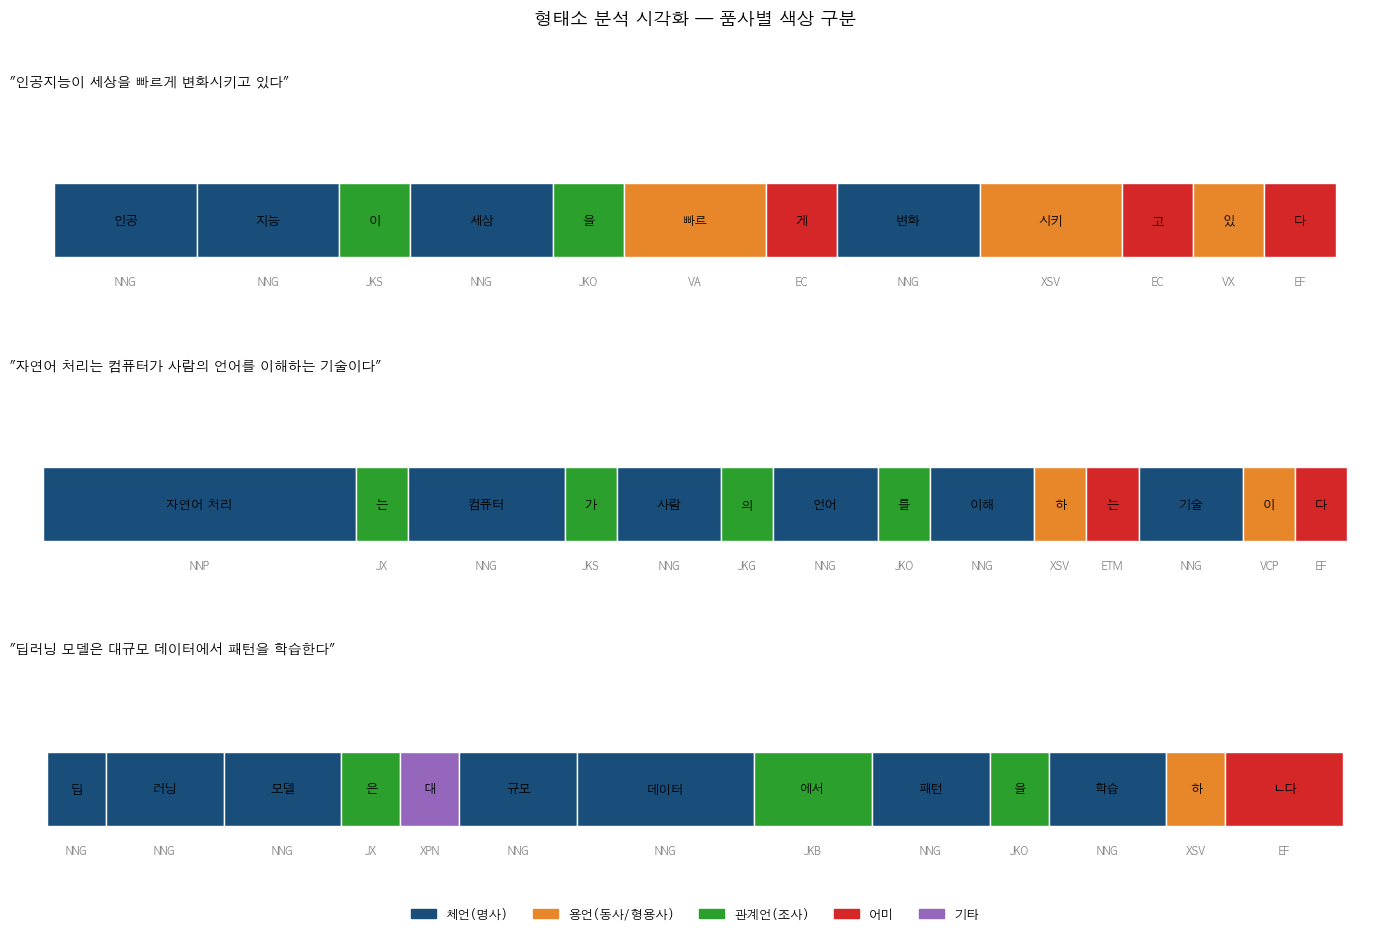

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'NanumGothic' not found.


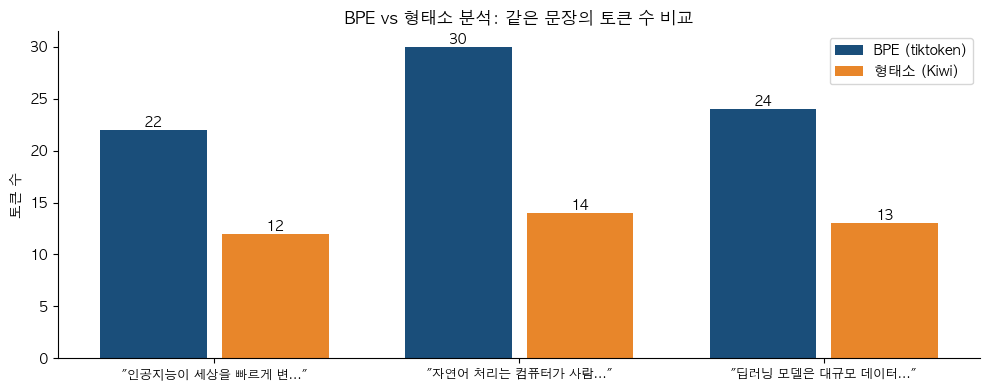

→ images/w02-bpe-vs-kiwi-chart.png 저장됨


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

# --- 1. 여러 문장의 형태소 분석 + 품사 분포 ---
sample_texts = [
    "인공지능이 세상을 빠르게 변화시키고 있다",
    "자연어 처리는 컴퓨터가 사람의 언어를 이해하는 기술이다",
    "딥러닝 모델은 대규모 데이터에서 패턴을 학습한다",
]

# 품사 카테고리별 색상
pos_colors = {
    "체언(명사)": "#1a4e7a",       # 진한 파랑
    "용언(동사/형용사)": "#e8862a", # 주황
    "관계언(조사)": "#2ca02c",      # 초록
    "어미": "#d62728",              # 빨강
    "기타": "#9467bd",              # 보라
}

def pos_category(tag):
    if tag.startswith("N"):  return "체언(명사)"
    if tag.startswith("V") or tag.startswith("XSV") or tag.startswith("XSA"): return "용언(동사/형용사)"
    if tag.startswith("J"):  return "관계언(조사)"
    if tag.startswith("E"):  return "어미"
    return "기타"

fig, axes = plt.subplots(len(sample_texts), 1, figsize=(14, 3 * len(sample_texts)))
if len(sample_texts) == 1: axes = [axes]

for ax, text in zip(axes, sample_texts):
    tokens = kw.tokenize(text)
    # 각 형태소를 색상 막대로 표시
    x_pos = 0
    for t in tokens:
        cat = pos_category(t.tag)
        color = pos_colors.get(cat, "#999999")
        width = max(len(t.form) * 0.8, 0.8)
        ax.barh(0, width, left=x_pos, height=0.6, color=color, edgecolor="white", linewidth=1)
        ax.text(x_pos + width/2, 0, t.form, ha="center", va="center", fontsize=9, fontweight="bold")
        ax.text(x_pos + width/2, -0.5, t.tag, ha="center", va="center", fontsize=7, color="gray")
        x_pos += width

    ax.set_xlim(-0.5, x_pos + 0.5)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'"{text}"', fontsize=10, loc="left", pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

# 범례
handles = [plt.Rectangle((0,0),1,1, color=c) for c in pos_colors.values()]
fig.legend(handles, pos_colors.keys(), loc="lower center", ncol=5, fontsize=9, frameon=False)
plt.suptitle("형태소 분석 시각화 — 품사별 색상 구분", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("images/w02-morpheme-viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ images/w02-morpheme-viz.png 저장됨")

# --- 2. BPE vs 형태소: 토큰 수 비교 막대 그래프 ---
fig2, ax2 = plt.subplots(figsize=(10, 4))

labels = [f'"{t[:15]}..."' if len(t) > 15 else f'"{t}"' for t in sample_texts]
bpe_counts = [len(enc.encode(t)) for t in sample_texts]
kiwi_counts = [len(kw.tokenize(t)) for t in sample_texts]

x = range(len(sample_texts))
bars1 = ax2.bar([i - 0.2 for i in x], bpe_counts, 0.35, label="BPE (tiktoken)", color="#1a4e7a")
bars2 = ax2.bar([i + 0.2 for i in x], kiwi_counts, 0.35, label="형태소 (Kiwi)", color="#e8862a")

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha="center", fontsize=10, fontweight="bold")
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha="center", fontsize=10, fontweight="bold")

ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("토큰 수")
ax2.set_title("BPE vs 형태소 분석: 같은 문장의 토큰 수 비교", fontweight="bold")
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("images/w02-bpe-vs-kiwi-chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ images/w02-bpe-vs-kiwi-chart.png 저장됨")

## 5. 나만의 BPE 토크나이저 만들기 🔧

BPE 알고리즘을 처음부터 직접 구현합니다.
1. 텍스트를 문자 단위로 분해
2. 가장 빈번한 인접 문자 쌍을 찾기
3. 병합하여 새 토큰으로 추가
4. 원하는 어휘 크기까지 반복

**이것이 GPT가 사용하는 알고리즘의 핵심 원리입니다!**

In [8]:
from collections import Counter

class MyBPE:
    """직접 구현하는 간이 BPE 토크나이저"""

    def __init__(self):
        self.merges = []      # 병합 규칙 리스트
        self.vocab = set()    # 현재 어휘

    def train(self, text, num_merges=15, verbose=True):
        """말뭉치에서 BPE 어휘를 학습"""
        # 1단계: 단어를 문자 단위로 분해 (공백 = 특수 토큰 _)
        words = text.split()
        word_freqs = Counter(words)

        # 각 단어를 문자 시퀀스로 변환
        splits = {}
        for word, freq in word_freqs.items():
            splits[word] = list(word) + ["</w>"]  # 단어 끝 표시

        # 초기 어휘
        self.vocab = set(c for word in splits for c in splits[word])
        if verbose:
            print(f"초기 어휘 ({len(self.vocab)}개): {sorted(self.vocab)}")
            print()

        for i in range(num_merges):
            # 2단계: 모든 인접 쌍의 빈도 계산
            pair_freqs = Counter()
            for word, freq in word_freqs.items():
                chars = splits[word]
                for a, b in zip(chars, chars[1:]):
                    pair_freqs[(a, b)] += freq

            if not pair_freqs:
                break

            # 3단계: 가장 빈번한 쌍 선택
            best_pair = pair_freqs.most_common(1)[0]
            (a, b), freq = best_pair
            merged = a + b

            # 4단계: 해당 쌍을 모든 단어에서 병합
            for word in splits:
                new_chars = []
                chars = splits[word]
                j = 0
                while j < len(chars):
                    if j < len(chars) - 1 and chars[j] == a and chars[j+1] == b:
                        new_chars.append(merged)
                        j += 2
                    else:
                        new_chars.append(chars[j])
                        j += 1
                splits[word] = new_chars

            self.merges.append((a, b))
            self.vocab.add(merged)

            if verbose:
                print(f"병합 {i+1:>2d}: ('{a}', '{b}') → '{merged}'  "
                      f"(빈도: {freq})")

        if verbose:
            print(f"\n최종 어휘 ({len(self.vocab)}개): {sorted(self.vocab)}")
            print(f"병합 규칙: {len(self.merges)}개")

        self._splits = splits
        return self

    def tokenize(self, text):
        """학습된 규칙으로 새 텍스트를 토큰화"""
        words = text.split()
        all_tokens = []

        for word in words:
            chars = list(word) + ["</w>"]

            # 학습된 병합 규칙을 순서대로 적용
            for (a, b) in self.merges:
                new_chars = []
                j = 0
                while j < len(chars):
                    if j < len(chars) - 1 and chars[j] == a and chars[j+1] == b:
                        new_chars.append(a + b)
                        j += 2
                    else:
                        new_chars.append(chars[j])
                        j += 1
                chars = new_chars

            all_tokens.extend(chars)

        return all_tokens

# ===== 학습 실행 =====
corpus = "low low low low low lowest lowest newer newer newer newer newer newer wider wider wider new new"
print("=" * 60)
print(f"학습 말뭉치: {corpus}")
print("=" * 60 + "\n")

bpe = MyBPE()
bpe.train(corpus, num_merges=10)

학습 말뭉치: low low low low low lowest lowest newer newer newer newer newer newer wider wider wider new new

초기 어휘 (11개): ['</w>', 'd', 'e', 'i', 'l', 'n', 'o', 'r', 's', 't', 'w']

병합  1: ('e', 'r') → 'er'  (빈도: 9)
병합  2: ('er', '</w>') → 'er</w>'  (빈도: 9)
병합  3: ('n', 'e') → 'ne'  (빈도: 8)
병합  4: ('ne', 'w') → 'new'  (빈도: 8)
병합  5: ('l', 'o') → 'lo'  (빈도: 7)
병합  6: ('lo', 'w') → 'low'  (빈도: 7)
병합  7: ('new', 'er</w>') → 'newer</w>'  (빈도: 6)
병합  8: ('low', '</w>') → 'low</w>'  (빈도: 5)
병합  9: ('w', 'i') → 'wi'  (빈도: 3)
병합 10: ('wi', 'd') → 'wid'  (빈도: 3)

최종 어휘 (21개): ['</w>', 'd', 'e', 'er', 'er</w>', 'i', 'l', 'lo', 'low', 'low</w>', 'n', 'ne', 'new', 'newer</w>', 'o', 'r', 's', 't', 'w', 'wi', 'wid']
병합 규칙: 10개


In [9]:
# 학습된 나만의 BPE로 새 텍스트를 토큰화!
print("=" * 60)
print("나의 BPE 토크나이저로 새 텍스트 토큰화")
print("=" * 60)

test_texts = [
    "low",          # 학습 데이터에 있던 단어
    "lowest",       # 학습 데이터에 있던 단어
    "newer",        # 학습 데이터에 있던 단어
    "lower",        # 학습 데이터에 없던 단어! (OOV 테스트)
    "newest",       # 학습 데이터에 없던 단어! (OOV 테스트)
    "widest",       # 학습 데이터에 없던 단어!
]

for text in test_texts:
    tokens = bpe.tokenize(text)
    in_corpus = "✓" if text in corpus.split() else "✗ (OOV)"
    print(f"  '{text}' → {tokens}  {in_corpus}")

print("\n→ 학습 데이터에 없던 'lower', 'newest'도")
print("  학습된 서브워드로 분해하여 처리할 수 있다!")
print("  이것이 BPE가 OOV를 해결하는 원리.")

나의 BPE 토크나이저로 새 텍스트 토큰화
  'low' → ['low</w>']  ✓
  'lowest' → ['low', 'e', 's', 't', '</w>']  ✓
  'newer' → ['newer</w>']  ✓
  'lower' → ['low', 'er</w>']  ✗ (OOV)
  'newest' → ['new', 'e', 's', 't', '</w>']  ✗ (OOV)
  'widest' → ['wid', 'e', 's', 't', '</w>']  ✗ (OOV)

→ 학습 데이터에 없던 'lower', 'newest'도
  학습된 서브워드로 분해하여 처리할 수 있다!
  이것이 BPE가 OOV를 해결하는 원리.


## 6. 도전 과제

스스로 시도해보세요:

1. **한국어 말뭉치로 BPE 학습**: 위의 `MyBPE`를 한국어 텍스트로 학습시켜보세요. 영어와 어떤 차이가 있나요?
2. **병합 횟수 실험**: `num_merges`를 5, 10, 20, 50으로 바꿔가며 토큰 수 변화를 관찰하세요.
3. **나만의 토큰화 규칙**: BPE 대신 "빈도 TOP-3 쌍만 병합" 또는 "모음-자음 경계에서만 분리" 같은 자기만의 규칙을 만들어보세요.

In [10]:
# 도전 1: 한국어 말뭉치로 BPE 학습
ko_corpus = ("자연어 처리 자연어 분석 자연어 이해 "
             "인공 지능 인공 신경망 인공 생명 "
             "기계 학습 기계 번역 기계 판독 "
             "딥 러닝 딥 페이크 딥 러닝 딥 러닝")

print("=" * 60)
print("한국어 말뭉치로 BPE 학습")
print("=" * 60 + "\n")

ko_bpe = MyBPE()
ko_bpe.train(ko_corpus, num_merges=8)

print("\n--- 한국어 BPE 토큰화 테스트 ---")
for text in ["자연어 처리", "인공 지능", "자연어 생성"]:
    tokens = ko_bpe.tokenize(text)
    print(f"  '{text}' → {tokens}")

한국어 말뭉치로 BPE 학습

초기 어휘 (32개): ['</w>', '경', '계', '공', '기', '능', '닝', '독', '딥', '러', '리', '망', '명', '번', '분', '생', '석', '습', '신', '어', '역', '연', '이', '인', '자', '지', '처', '크', '판', '페', '학', '해']

병합  1: ('딥', '</w>') → '딥</w>'  (빈도: 4)
병합  2: ('자', '연') → '자연'  (빈도: 3)
병합  3: ('자연', '어') → '자연어'  (빈도: 3)
병합  4: ('자연어', '</w>') → '자연어</w>'  (빈도: 3)
병합  5: ('인', '공') → '인공'  (빈도: 3)
병합  6: ('인공', '</w>') → '인공</w>'  (빈도: 3)
병합  7: ('기', '계') → '기계'  (빈도: 3)
병합  8: ('기계', '</w>') → '기계</w>'  (빈도: 3)

최종 어휘 (40개): ['</w>', '경', '계', '공', '기', '기계', '기계</w>', '능', '닝', '독', '딥', '딥</w>', '러', '리', '망', '명', '번', '분', '생', '석', '습', '신', '어', '역', '연', '이', '인', '인공', '인공</w>', '자', '자연', '자연어', '자연어</w>', '지', '처', '크', '판', '페', '학', '해']
병합 규칙: 8개

--- 한국어 BPE 토큰화 테스트 ---
  '자연어 처리' → ['자연어</w>', '처', '리', '</w>']
  '인공 지능' → ['인공</w>', '지', '능', '</w>']
  '자연어 생성' → ['자연어</w>', '생', '성', '</w>']
